# Decision Trees

**Scenario:**  
You are a data scientist at a bank. The credit team wants an automated loan approval system that is not a black box — they need to understand **why** the model made each decision. A manager should be able to look at a prediction and trace it back to a series of yes/no questions.

Decision Trees are perfect for this: they make predictions by asking a sequence of threshold questions on the features.

| Section | Topic |
|---|---|
| 1 | Intuition — Decisions as a Tree of Questions |
| 2 | Splitting Criteria: Gini Impurity & Entropy |
| 3 | Information Gain |
| 4 | Building a Tree Step by Step |
| 5 | Visualising the Decision Tree |
| 6 | Tree Depth & Overfitting |
| 7 | Pruning — Controlling Tree Complexity |
| 8 | Feature Importance |
| 9 | Regression Trees |
| 10 | Strengths, Weaknesses & Practical Tips |
| 11 | Summary |

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    plot_tree, export_text
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, validation_curve
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


---
## 1. Intuition — Decisions as a Tree of Questions

A Decision Tree makes predictions by asking a series of **threshold questions** on the input features:

```
Is credit_score > 650?
├── YES → Is income > 50k?
│         ├── YES → APPROVED
│         └── NO  → Is debt_ratio < 0.35?
│                   ├── YES → APPROVED
│                   └── NO  → REJECTED
└── NO  → Is employment_years > 5?
          ├── YES → PENDING REVIEW
          └── NO  → REJECTED
```

The tree learns **which questions to ask** and **which threshold to use** from the training data — choosing the split that best separates the classes at each node.

In [2]:
# Build the loan dataset
N = 600

credit_score     = np.random.normal(650, 80, N).clip(300, 850)
income_k         = np.random.lognormal(4.0, 0.5, N).clip(20, 300)
debt_ratio       = np.random.uniform(0.05, 0.80, N)
employment_years = np.random.exponential(6, N).clip(0, 40)
num_accounts     = np.random.randint(1, 15, N).astype(float)
loan_amount_k    = np.random.uniform(5, 200, N)

# Approval score (higher = more likely approved)
approval_score = (
    0.005  * credit_score
    + 0.008 * income_k
    - 2.5   * debt_ratio
    + 0.05  * employment_years
    + 0.05  * num_accounts
    - 0.003 * loan_amount_k
    + np.random.normal(0, 0.5, N)
)

approved = (approval_score > approval_score.mean()).astype(int)

df = pd.DataFrame({
    'credit_score':     credit_score.round(0),
    'income_k':         income_k.round(1),
    'debt_ratio':       debt_ratio.round(3),
    'employment_years': employment_years.round(1),
    'num_accounts':     num_accounts,
    'loan_amount_k':    loan_amount_k.round(1),
    'approved':         approved
})

print(f'Loan dataset: {df.shape}')
print()
print('Approval distribution:')
for label, count in df['approved'].value_counts().sort_index().items():
    status = 'Approved' if label == 1 else 'Rejected'
    print(f'  {label} ({status}): {count} ({count/N*100:.1f}%)')
print()
df.head(8)

Loan dataset: (600, 7)

Approval distribution:
  0 (Rejected): 296 (49.3%)
  1 (Approved): 304 (50.7%)



,credit_score,income_k,debt_ratio,employment_years,num_accounts,loan_amount_k,approved
0,690.0,79.7,0.083,4.1,5.0,127.4,1
1,639.0,34.4,0.525,10.6,8.0,80.2,1
2,702.0,84.3,0.764,2.4,8.0,187.6,0
3,772.0,107.5,0.501,1.1,4.0,110.7,0
4,631.0,67.1,0.664,7.5,12.0,188.2,0
5,631.0,139.5,0.713,10.5,11.0,48.0,1
6,776.0,37.1,0.221,0.6,11.0,146.5,1
7,711.0,29.3,0.209,1.6,1.0,125.4,0


---
## 2. Splitting Criteria — Gini Impurity & Entropy

At each node, the tree chooses the split that creates the **purest** child nodes — where nodes contain mostly one class.

### Gini Impurity

$$\text{Gini}(t) = 1 - \sum_{c} p_c^2$$

- $p_c$ = fraction of samples of class $c$ at node $t$
- Gini = 0: perfectly pure (all one class) — best possible
- Gini = 0.5: perfectly impure (50/50 split of 2 classes) — worst possible

### Entropy (Information)

$$H(t) = -\sum_{c} p_c \log_2(p_c)$$

- Entropy = 0: perfectly pure
- Entropy = 1: perfectly impure (for binary)

Both measures are equivalent in practice. Gini is faster to compute (no log).

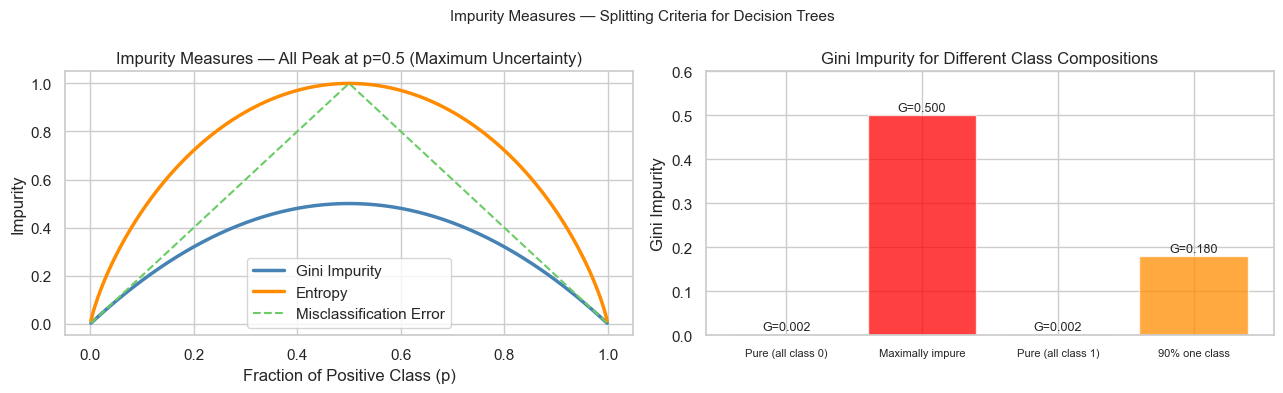

The tree always splits to REDUCE impurity.
A good split: parent has high impurity, children have low impurity.


In [3]:
def gini(p):
    """p = fraction of positive class. Returns Gini impurity."""
    return 1 - (p**2 + (1-p)**2)

def entropy(p):
    """p = fraction of positive class. Returns entropy."""
    eps = 1e-10
    p   = np.clip(p, eps, 1 - eps)
    return -(p * np.log2(p) + (1-p) * np.log2(1-p))

p_values = np.linspace(0.001, 0.999, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Gini vs Entropy
axes[0].plot(p_values, gini(p_values),    color='steelblue', lw=2.5, label='Gini Impurity')
axes[0].plot(p_values, entropy(p_values), color='darkorange', lw=2.5, label='Entropy')
axes[0].plot(p_values, 2 * np.minimum(p_values, 1-p_values), 'g--', lw=1.5, label='Misclassification Error')
axes[0].set_xlabel('Fraction of Positive Class (p)')
axes[0].set_ylabel('Impurity')
axes[0].set_title('Impurity Measures — All Peak at p=0.5 (Maximum Uncertainty)')
axes[0].legend()

# Right: Annotate key points
examples = [
    (0.0,  'Pure (all class 0)', 'steelblue'),
    (0.5,  'Maximally impure', 'red'),
    (1.0,  'Pure (all class 1)', 'seagreen'),
    (0.9,  '90% one class', 'darkorange'),
]
ax2 = axes[1]
for p_ex, label, colour in examples:
    g = gini(np.clip(p_ex, 0.001, 0.999))
    ax2.bar(label, g, color=colour, alpha=0.75, edgecolor='white')
    ax2.text(label, g + 0.01, f'G={g:.3f}', ha='center', fontsize=9)

ax2.set_ylabel('Gini Impurity')
ax2.set_title('Gini Impurity for Different Class Compositions')
ax2.set_ylim(0, 0.6)
ax2.tick_params(axis='x', labelsize=8)

plt.suptitle('Impurity Measures — Splitting Criteria for Decision Trees', fontsize=11)
plt.tight_layout()
plt.show()

print('The tree always splits to REDUCE impurity.')
print('A good split: parent has high impurity, children have low impurity.')

---
## 3. Information Gain — Choosing the Best Split

**Information Gain** measures how much a split reduces impurity:

$$\text{IG}(t, \text{split}) = \text{Impurity}(t) - \sum_{\text{child}} \frac{n_{\text{child}}}{n_t} \cdot \text{Impurity}(\text{child})$$

The tree greedily picks the split with the highest Information Gain at each node.

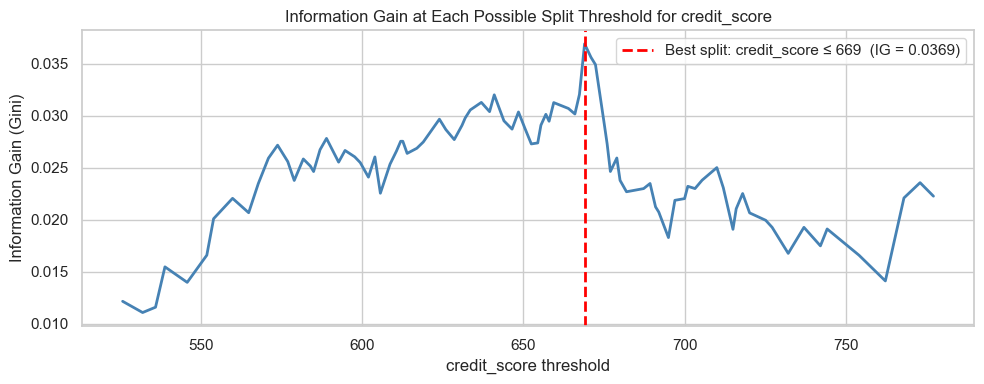

Best Information Gain per feature (single best split):

          credit_score: IG = 0.03692  ██████████████████
              income_k: IG = 0.01381  ██████
            debt_ratio: IG = 0.12719  ███████████████████████████████████████████████████████████████
      employment_years: IG = 0.02690  █████████████
          num_accounts: IG = 0.01147  █████
         loan_amount_k: IG = 0.00942  ████

Best feature to split on first: debt_ratio


In [4]:
def information_gain(y, y_left, y_right, criterion='gini'):
    """Compute information gain of a binary split."""
    n       = len(y)
    n_left  = len(y_left)
    n_right = len(y_right)

    def impurity(labels):
        if len(labels) == 0:
            return 0.0
        p = labels.mean()
        if criterion == 'gini':
            return gini(p)
        else:
            return entropy(np.clip(p, 1e-10, 1-1e-10))

    parent_imp = impurity(y)
    child_imp  = (n_left/n) * impurity(y_left) + (n_right/n) * impurity(y_right)
    return parent_imp - child_imp


# Find the best split threshold for credit_score
feature = 'credit_score'
y = df['approved'].values
x = df[feature].values

thresholds = np.percentile(x, np.arange(5, 96, 1))
gains = []

for thresh in thresholds:
    left_mask  = x <= thresh
    right_mask = ~left_mask
    ig = information_gain(y, y[left_mask], y[right_mask])
    gains.append(ig)

best_thresh = thresholds[np.argmax(gains)]
best_ig     = max(gains)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, gains, color='steelblue', lw=2)
ax.axvline(best_thresh, color='red', ls='--', lw=2,
           label=f'Best split: {feature} ≤ {best_thresh:.0f}  (IG = {best_ig:.4f})')
ax.set_xlabel(f'{feature} threshold')
ax.set_ylabel('Information Gain (Gini)')
ax.set_title(f'Information Gain at Each Possible Split Threshold for {feature}')
ax.legend()
plt.tight_layout()
plt.show()

# Compare information gain across all features
features = ['credit_score', 'income_k', 'debt_ratio', 'employment_years', 'num_accounts', 'loan_amount_k']
print('Best Information Gain per feature (single best split):')
print()
feature_igs = []
for feat in features:
    x_f = df[feat].values
    thresh_f = np.percentile(x_f, np.arange(5, 96, 1))
    ig_f = max([
        information_gain(y, y[x_f <= t], y[x_f > t])
        for t in thresh_f
    ])
    feature_igs.append(ig_f)
    bar = '█' * int(ig_f * 500)
    print(f'  {feat:>20}: IG = {ig_f:.5f}  {bar}')

best_feat = features[np.argmax(feature_igs)]
print(f'\nBest feature to split on first: {best_feat}')

---
## 4. Building a Tree Step by Step

Let us watch the algorithm build the first 2 levels of the tree manually.

In [5]:
# Use just 2 features for step-by-step illustration
X2 = df[['credit_score', 'debt_ratio']].values
y2 = df['approved'].values

# Fit a very shallow tree (depth 2)
dt_shallow = DecisionTreeClassifier(max_depth=2, criterion='gini', random_state=42)
dt_shallow.fit(X2, y2)

# Print the tree rules as text
tree_text = export_text(dt_shallow, feature_names=['credit_score', 'debt_ratio'])
print('Decision Tree Rules (depth=2):')
print(tree_text)

print('How to read this:')
print('  |--- feature <= threshold  : go LEFT into this branch')
print('  |--- feature >  threshold  : go RIGHT into this branch')
print('  class: X                   : prediction at this leaf node')
print('  (0 = Rejected, 1 = Approved)')

Decision Tree Rules (depth=2):
|--- debt_ratio <= 0.49
|   |--- credit_score <= 669.50
|   |   |--- class: 1
|   |--- credit_score >  669.50
|   |   |--- class: 1
|--- debt_ratio >  0.49
|   |--- credit_score <= 779.50
|   |   |--- class: 0
|   |--- credit_score >  779.50
|   |   |--- class: 1

How to read this:
  |--- feature <= threshold  : go LEFT into this branch
  |--- feature >  threshold  : go RIGHT into this branch
  class: X                   : prediction at this leaf node
  (0 = Rejected, 1 = Approved)


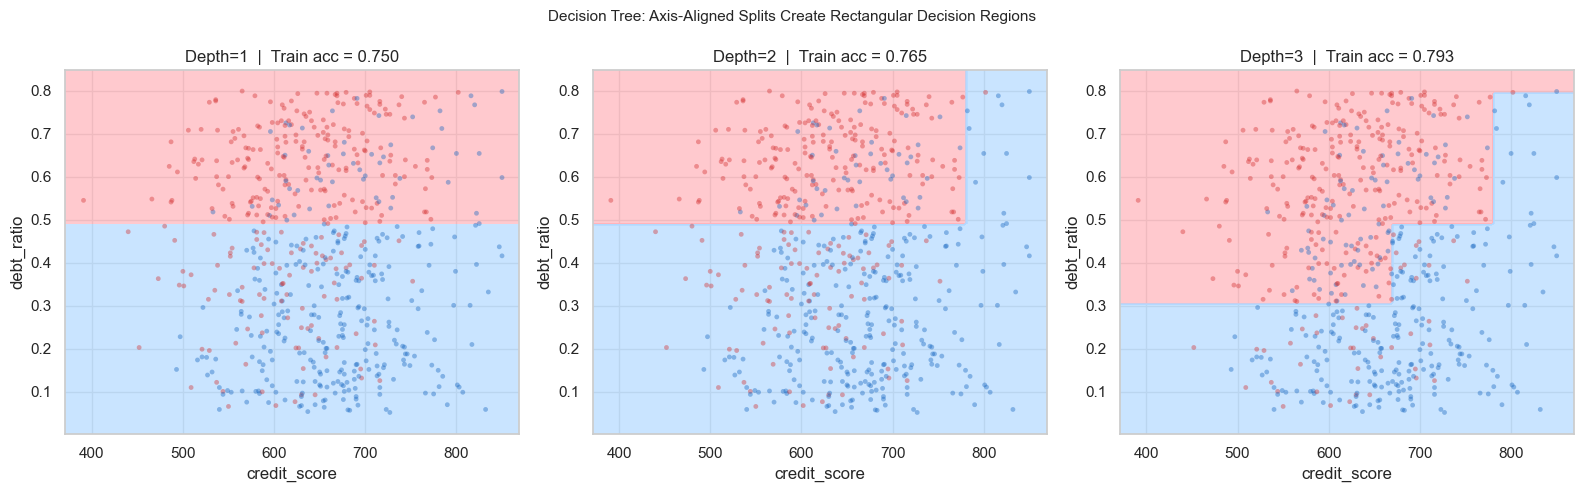

Each split adds a horizontal or vertical line — cuts the feature space into rectangles.
Deeper tree → more rectangles → finer-grained but more overfit.


In [6]:
# Visualise the splits as regions on a 2D plot
from matplotlib.colors import ListedColormap

scaler_2d = __import__('sklearn').preprocessing.StandardScaler()

h   = 3.0
x_min, x_max = X2[:, 0].min() - 20, X2[:, 0].max() + 20
y_min_g, y_max_g = X2[:, 1].min() - 0.05, X2[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min_g, y_max_g, 0.005))

cmap_bg  = ListedColormap(['#ffb3ba', '#b3d9ff'])
cmap_pts = ListedColormap(['#d32f2f', '#1565c0'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, depth, title in zip(axes, [1, 2, 3], ['Depth=1', 'Depth=2', 'Depth=3']):
    dt = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42)
    dt.fit(X2, y2)

    Z = dt.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.7)
    ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap=cmap_pts,
               alpha=0.4, s=12, edgecolors='none')

    acc = dt.score(X2, y2)
    ax.set_xlabel('credit_score')
    ax.set_ylabel('debt_ratio')
    ax.set_title(f'{title}  |  Train acc = {acc:.3f}')

plt.suptitle('Decision Tree: Axis-Aligned Splits Create Rectangular Decision Regions', fontsize=11)
plt.tight_layout()
plt.show()

print('Each split adds a horizontal or vertical line — cuts the feature space into rectangles.')
print('Deeper tree → more rectangles → finer-grained but more overfit.')

---
## 5. Visualising the Decision Tree

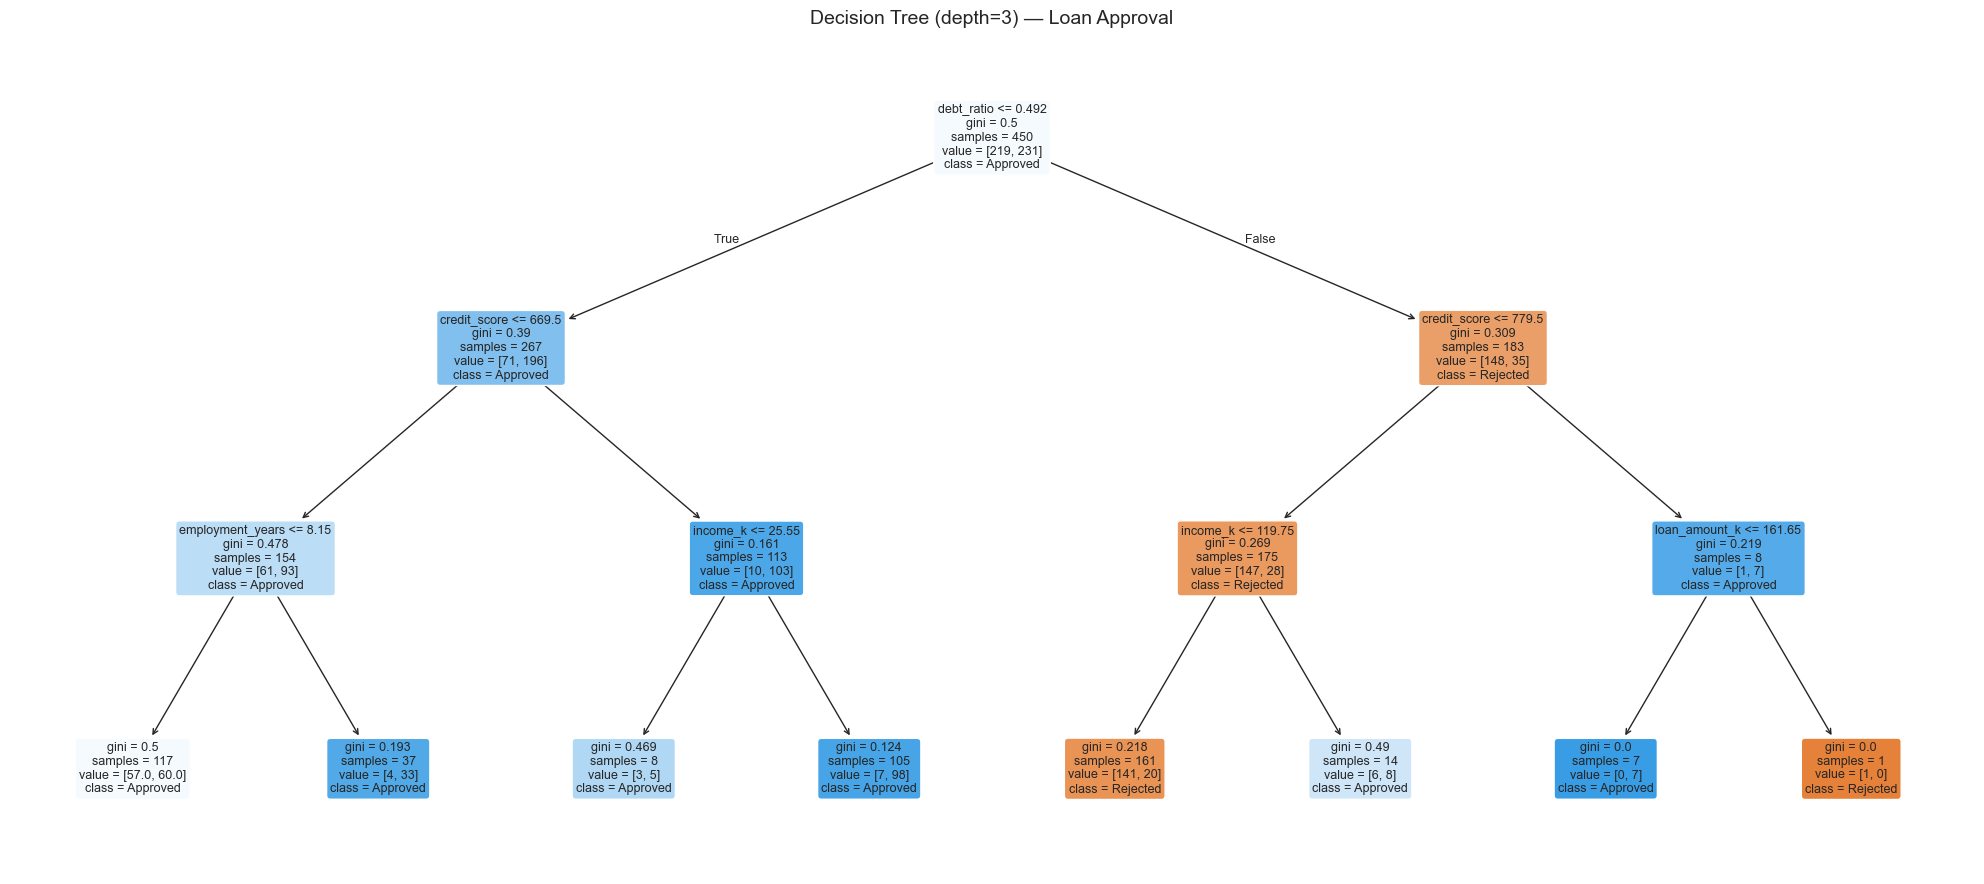

Reading each node:
  feature <= threshold  : split condition
  gini = X              : impurity at this node
  samples = X           : number of training samples reaching this node
  value = [X, Y]        : count of [Rejected, Approved] samples
  class = X             : majority class at this node

Depth-3 tree test accuracy: 0.7600


In [7]:
# Full feature tree — depth=3 for readability
features = ['credit_score', 'income_k', 'debt_ratio', 'employment_years', 'num_accounts', 'loan_amount_k']
X_full = df[features].values
y_full = df['approved'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.25, random_state=42)

dt_vis = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt_vis.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    dt_vis,
    feature_names=features,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Decision Tree (depth=3) — Loan Approval', fontsize=14)
plt.tight_layout()
plt.show()

print('Reading each node:')
print('  feature <= threshold  : split condition')
print('  gini = X              : impurity at this node')
print('  samples = X           : number of training samples reaching this node')
print('  value = [X, Y]        : count of [Rejected, Approved] samples')
print('  class = X             : majority class at this node')
print()
print(f'Depth-3 tree test accuracy: {dt_vis.score(X_te, y_te):.4f}')

---
## 6. Tree Depth & Overfitting

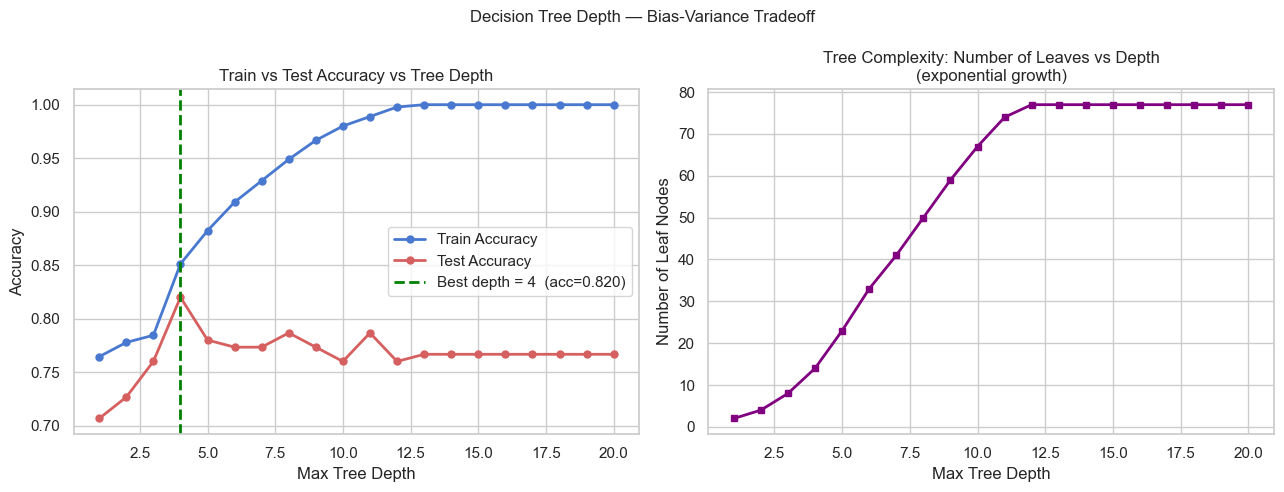

Depth 1:        2 leaf  — very underfitting
Depth 4:        14 leaves — best generalisation
Depth 20:       77 leaves — memorises training data


In [8]:
depths = range(1, 21)
train_accs = []
test_accs  = []
n_leaves   = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr, y_tr)
    train_accs.append(accuracy_score(y_tr, dt.predict(X_tr)))
    test_accs.append(accuracy_score(y_te,  dt.predict(X_te)))
    n_leaves.append(dt.get_n_leaves())

best_depth = list(depths)[np.argmax(test_accs)]
best_test_acc = max(test_accs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(depths), train_accs, 'b-o', lw=2, ms=5, label='Train Accuracy')
axes[0].plot(list(depths), test_accs,  'r-o', lw=2, ms=5, label='Test Accuracy')
axes[0].axvline(best_depth, color='green', ls='--', lw=2,
               label=f'Best depth = {best_depth}  (acc={best_test_acc:.3f})')
axes[0].set_xlabel('Max Tree Depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy vs Tree Depth')
axes[0].legend()

axes[1].plot(list(depths), n_leaves, 'purple', lw=2, marker='s', ms=5)
axes[1].set_xlabel('Max Tree Depth')
axes[1].set_ylabel('Number of Leaf Nodes')
axes[1].set_title('Tree Complexity: Number of Leaves vs Depth\n(exponential growth)')

plt.suptitle('Decision Tree Depth — Bias-Variance Tradeoff', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Depth 1:        {n_leaves[0]} leaf  — very underfitting')
print(f'Depth {best_depth}:        {n_leaves[best_depth-1]} leaves — best generalisation')
print(f'Depth {list(depths)[-1]}:       {n_leaves[-1]} leaves — memorises training data')

---
## 7. Pruning — Controlling Tree Complexity

**Pre-pruning:** Stop growing the tree early using constraints:
- `max_depth`: maximum depth of the tree
- `min_samples_split`: minimum samples required to split a node
- `min_samples_leaf`: minimum samples required at each leaf
- `max_leaf_nodes`: maximum number of leaves

**Post-pruning (Cost-Complexity Pruning):** Grow a full tree, then prune branches that don't improve generalisation:

$$\text{Cost-Complexity} = \text{Impurity} + \alpha \times \text{Number of Leaves}$$

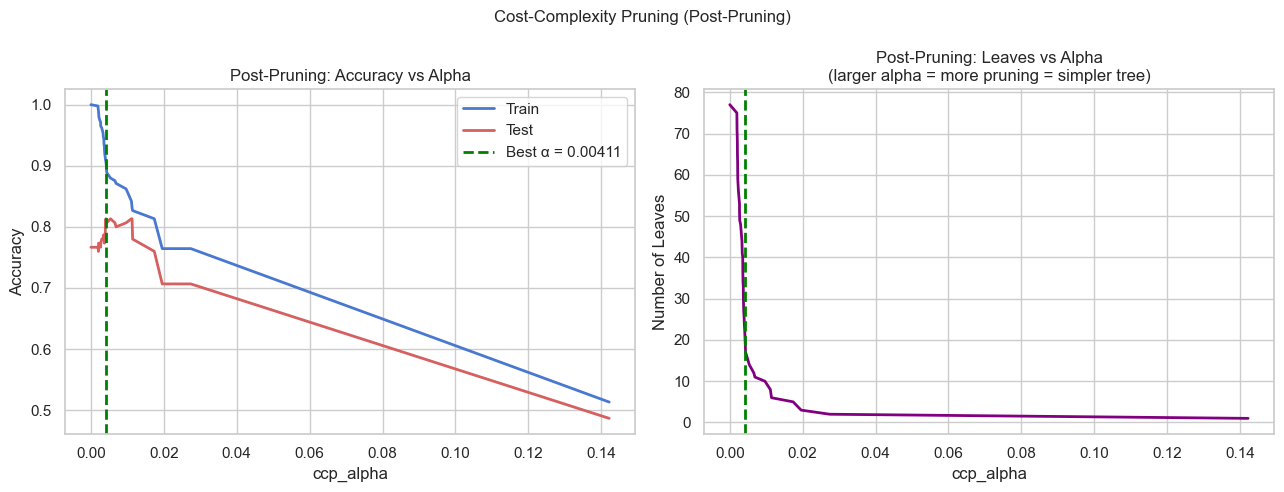

Best ccp_alpha = 0.00411
Resulting tree: 22 leaves
Test accuracy:  0.8133


In [9]:
# Cost-Complexity Pruning path
full_tree = DecisionTreeClassifier(random_state=42)
path      = full_tree.cost_complexity_pruning_path(X_tr, y_tr)
alphas, impurities = path.ccp_alphas, path.impurities

# Train one tree per alpha and evaluate
clfs = []
for alpha in alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt.fit(X_tr, y_tr)
    clfs.append(dt)

train_scores = [c.score(X_tr, y_tr) for c in clfs]
test_scores  = [c.score(X_te, y_te) for c in clfs]
leaf_counts  = [c.get_n_leaves() for c in clfs]

best_ccp_idx   = np.argmax(test_scores)
best_ccp_alpha = alphas[best_ccp_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(alphas, train_scores, 'b-', lw=2, label='Train')
axes[0].plot(alphas, test_scores,  'r-', lw=2, label='Test')
axes[0].axvline(best_ccp_alpha, color='green', ls='--', lw=2,
               label=f'Best α = {best_ccp_alpha:.5f}')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Post-Pruning: Accuracy vs Alpha')
axes[0].legend()

axes[1].plot(alphas, leaf_counts, 'purple', lw=2)
axes[1].axvline(best_ccp_alpha, color='green', ls='--', lw=2)
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Number of Leaves')
axes[1].set_title('Post-Pruning: Leaves vs Alpha\n(larger alpha = more pruning = simpler tree)')

plt.suptitle('Cost-Complexity Pruning (Post-Pruning)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Best ccp_alpha = {best_ccp_alpha:.5f}')
print(f'Resulting tree: {leaf_counts[best_ccp_idx]} leaves')
print(f'Test accuracy:  {test_scores[best_ccp_idx]:.4f}')

---
## 8. Feature Importance

Feature Importances (Mean Decrease in Gini Impurity):

            debt_ratio:  0.6008  ██████████████████████████████
          credit_score:  0.2173  ██████████
      employment_years:  0.0914  ████
              income_k:  0.0537  ██
          num_accounts:  0.0226  █
         loan_amount_k:  0.0143  


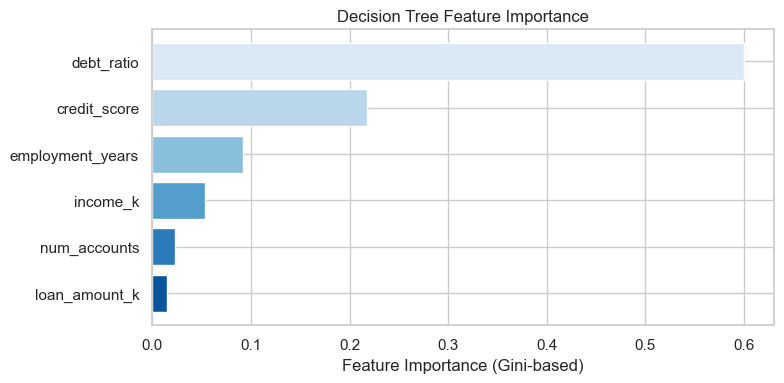


Importance = total weighted Gini reduction from all splits using this feature.
Features used near the root (on many samples) get high importance.

For more reliable importance: use permutation importance (sklearn's permutation_importance).


In [10]:
# Best tree for feature importance
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_tr, y_tr)

importances = dt_best.feature_importances_
feat_imp_df = pd.DataFrame({'feature': features, 'importance': importances})\
                .sort_values('importance', ascending=False)

print('Feature Importances (Mean Decrease in Gini Impurity):')
print()
for _, row in feat_imp_df.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:>20}:  {row['importance']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(8, 4))
colours = sns.color_palette('Blues_r', len(features))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
        color=colours, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini-based)')
ax.set_title('Decision Tree Feature Importance')
plt.tight_layout()
plt.show()

print()
print('Importance = total weighted Gini reduction from all splits using this feature.')
print('Features used near the root (on many samples) get high importance.')
print()
print('Warning: this measure is biased toward high-cardinality continuous features.')
print('For more reliable importance: use permutation importance (sklearn\'s permutation_importance).')

---
## 9. Regression Trees

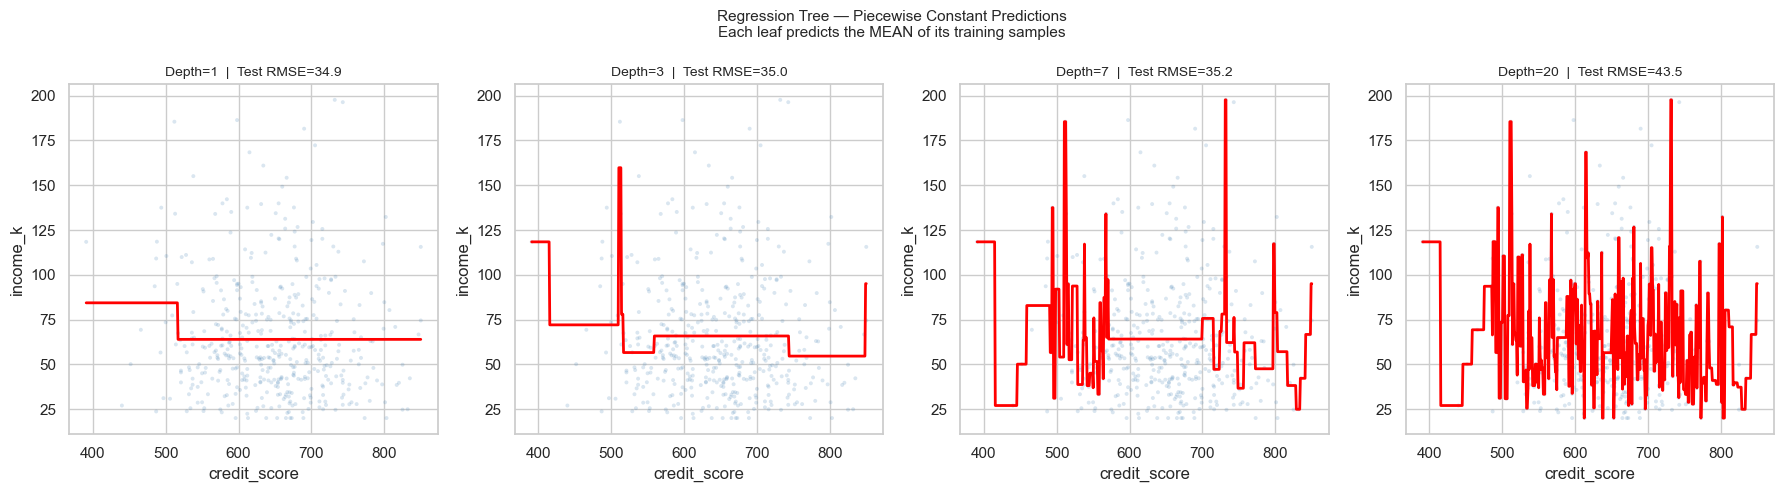

Regression tree splits use MSE (variance) instead of Gini/Entropy as the criterion.
Each leaf predicts the mean of the training samples that reach it.
The prediction is always a horizontal step function — piecewise constant.


In [11]:
# Regression tree: predict income from credit_score
# (showing piecewise constant nature)
X_reg = df[['credit_score']].values
y_reg = df['income_k'].values

X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

depths_reg = [1, 3, 7, 20]
x_plot = np.linspace(X_reg.min(), X_reg.max(), 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, d in zip(axes, depths_reg):
    dtr = DecisionTreeRegressor(max_depth=d, random_state=42)
    dtr.fit(X_reg_tr, y_reg_tr)

    y_plot = dtr.predict(x_plot)
    rmse_te = np.sqrt(mean_squared_error(y_reg_te, dtr.predict(X_reg_te)))

    ax.scatter(X_reg_tr, y_reg_tr, alpha=0.2, color='steelblue', s=8, edgecolors='none')
    ax.plot(x_plot, y_plot, color='red', lw=2)
    ax.set_title(f'Depth={d}  |  Test RMSE={rmse_te:.1f}', fontsize=10)
    ax.set_xlabel('credit_score')
    ax.set_ylabel('income_k')

plt.suptitle('Regression Tree — Piecewise Constant Predictions\n'
             'Each leaf predicts the MEAN of its training samples', fontsize=11)
plt.tight_layout()
plt.show()

print('Regression tree splits use MSE (variance) instead of Gini/Entropy as the criterion.')
print('Each leaf predicts the mean of the training samples that reach it.')
print('The prediction is always a horizontal step function — piecewise constant.')

---
## 10. Strengths, Weaknesses & Practical Tips

### Strengths
- **Interpretable:** Can be visualised and explained to non-technical stakeholders
- **No scaling needed:** Tree splits on thresholds — scale doesn't matter
- **Handles mixed types:** Works with continuous and categorical features naturally
- **Non-linear:** Captures complex interactions without feature engineering
- **Fast:** O(n log n) for training

### Weaknesses
- **Overfitting:** Unrestricted trees memorise training data
- **Unstable:** Small changes in data → very different tree structure
- **Axis-aligned splits:** Cannot capture diagonal decision boundaries efficiently
- **Biased toward high-cardinality features** in feature importance
- **Not competitive alone:** Usually outperformed by Random Forests or Gradient Boosting

In [12]:
# Demonstrate instability: two trees trained on slightly different subsets
print('Tree Instability Demonstration:')
print()
print('Training on 95% of data (two different random subsets):')
print()

for i, seed in enumerate([42, 123]):
    np.random.seed(seed)
    idx = np.random.choice(len(X_tr), size=int(0.95 * len(X_tr)), replace=False)
    X_sub, y_sub = X_tr[idx], y_tr[idx]

    dt_i = DecisionTreeClassifier(max_depth=3, random_state=42)
    dt_i.fit(X_sub, y_sub)

    root_feature = features[dt_i.tree_.feature[0]]
    root_thresh  = dt_i.tree_.threshold[0]
    test_acc     = dt_i.score(X_te, y_te)

    print(f'  Subset {i+1}: Root split = {root_feature} ≤ {root_thresh:.1f}  |  Test acc = {test_acc:.4f}')

print()
print('The root split can change significantly with small data variations.')
print('Solution: Random Forests — average many unstable trees to get a stable model.')

Tree Instability Demonstration:

Training on 95% of data (two different random subsets):

  Subset 1: Root split = debt_ratio ≤ 0.5  |  Test acc = 0.7600
  Subset 2: Root split = debt_ratio ≤ 0.5  |  Test acc = 0.7467

The root split can change significantly with small data variations.
Solution: Random Forests — average many unstable trees to get a stable model.


---
## 11. Summary

| Concept | Key takeaway |
|---|---|
| **Splitting criterion** | Gini or Entropy — measures impurity at each node |
| **Information Gain** | How much a split reduces impurity — tree always picks the maximum |
| **Tree depth** | Main hyperparameter — controls bias-variance tradeoff |
| **Pre-pruning** | max_depth, min_samples_split, min_samples_leaf |
| **Post-pruning** | ccp_alpha — trim branches that don't improve test performance |
| **Feature importance** | Total weighted Gini reduction across all splits using that feature |
| **Regression trees** | Same algorithm, uses MSE as criterion, predicts leaf mean |
| **Instability** | Small data changes → very different tree — motivates Random Forests |

**Quick reference — key parameters:**
```python
DecisionTreeClassifier(
    criterion='gini',       # or 'entropy'
    max_depth=5,            # most important — prevents overfitting
    min_samples_split=20,   # node must have >= 20 samples to be split
    min_samples_leaf=10,    # each leaf must have >= 10 samples
    ccp_alpha=0.01,         # post-pruning strength
    random_state=42
)
```

---
**Next:** Bagging & Random Forests — take many unstable decision trees and combine them into a powerful, stable ensemble.